In [ ]:
#EDA
import pandas as pd
df=pd.read_csv('Sample data (1).xlsx - Sheet1.csv')
print("FIRST 5 ROWS:\n",df.head())
print("\nDataset shape:",df.shape)
print("\nDATASET INFO:",df.info())
print("\nCOLUMNS:",df.columns.tolist())
print(df.describe())



FIRST 5 ROWS:
       Segment  Country    Product Discount Band  Units Sold  \
0  Government  Germany  Carretera           NaN      1513.0   
1  Government  Germany      Paseo           NaN      1006.0   
2  Government   Canada      Paseo           NaN      1725.0   
3  Government  Germany      Paseo           NaN      1513.0   
4  Government  Germany       Velo           NaN      1006.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts     Sales  \
0                    3         350     529550.0        0.0  529550.0   
1                   10         350     352100.0        0.0  352100.0   
2                   10         350     603750.0        0.0  603750.0   
3                   10         350     529550.0        0.0  529550.0   
4                  120         350     352100.0        0.0  352100.0   

       COGS    Profit       Date  Month Number Month Name  Year  
0  393380.0  136170.0  01-Dec-14            12   December  2014  
1  261560.0   90540.0  01-Jun-14         

In [27]:

print("\nmISSING VALUES:\n",df.isnull().sum())
print(df['Discount Band'].unique())
print("\ncounting values in discount band:\n",df['Discount Band'].value_counts())
df['Discount Band']=df['Discount Band'].fillna(df['Discount Band'].mode()[0])
print("\ndiscount band after filling missing values:\n",df['Discount Band'])


mISSING VALUES:
 Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
 Sales                 0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64
<ArrowStringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

counting values in discount band:
 Discount Band
High      298
Medium    242
Low       160
Name: count, dtype: int64

discount band after filling missing values:
 0      High
1      High
2      High
3      High
4      High
       ... 
695    High
696    High
697    High
698    High
699    High
Name: Discount Band, Length: 700, dtype: str


In [43]:
#REGRESSION MODEL
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
X=df[['Units Sold','Manufacturing Price','Sale Price']]
y=df[' Sales']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print("\nR2:",r2)
print("RMSE",rmse)
print("MEAN ABSOLUTE ERROR:",mae)
print("MEAN SQUARE ERROR:",mse)





R2: 0.762339997458229
RMSE 114727.2960361597
MEAN ABSOLUTE ERROR: 83644.48058984755
MEAN SQUARE ERROR: 13162352455.768625


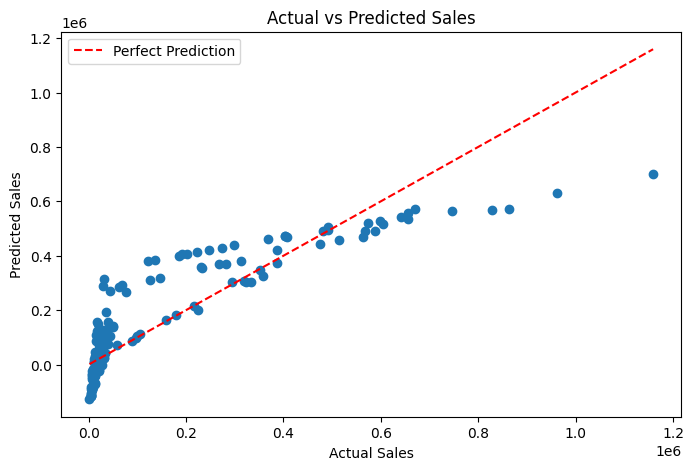

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--',label='Perfect Prediction')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()